In [23]:
# website data analysis

#IMPORTING LIBRABRIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("data-export (1).csv")


# Data Cleaning
df.columns = df.iloc[0]
df = df.drop(index=0).reset_index(drop=True)
df.columns = ["channel group","datehour","Users", "Sessions","Engaged sessions","Average engagement time per session","Engaged sessions per user","Events per session","Engagement rate","Event count"]


df["datehour"] = pd.to_datetime(df["datehour"], format="%Y%m%d%H", errors='coerce')
num_col = df.columns.drop(["channel group", 'datehour'])
df[num_col]= df[num_col].apply(pd.to_numeric, errors='coerce')
df['hour']= df['datehour'].dt.hour
df.describe()

,datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


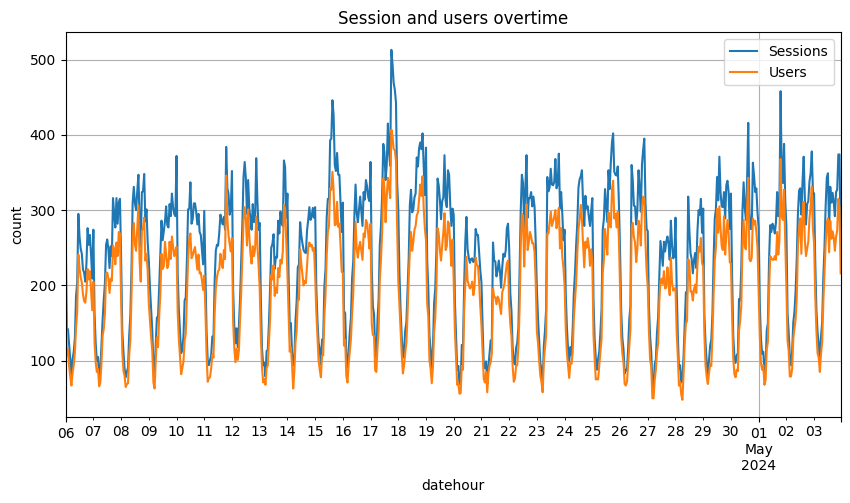

In [25]:
# visualisation 
# sessions and users over time

plt.figure(figsize=(10,5))
df.groupby("datehour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.grid(linestyle='-')
plt.title("Session and users overtime")
plt.xlabel("datehour")
plt.ylabel("count")
plt.show()

C:\Users\JAY\AppData\Local\Temp\ipykernel_23836\3778729816.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="channel group", y="Users", estimator=np.sum, palette='viridis')


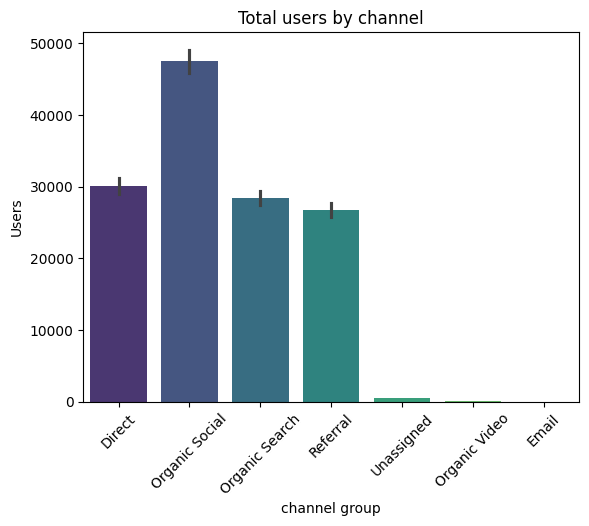

In [32]:
# Total Users by channels

plt.Figure(figsize=(8,5))
sns.barplot(data=df, x="channel group", y="Users", estimator=np.sum, palette='viridis')
plt.title("Total users by channel")
plt.xticks(rotation=45)
plt.show()

C:\Users\JAY\AppData\Local\Temp\ipykernel_23836\1544786355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="channel group", y="Average engagement time per session", estimator=np.mean, palette='magma')


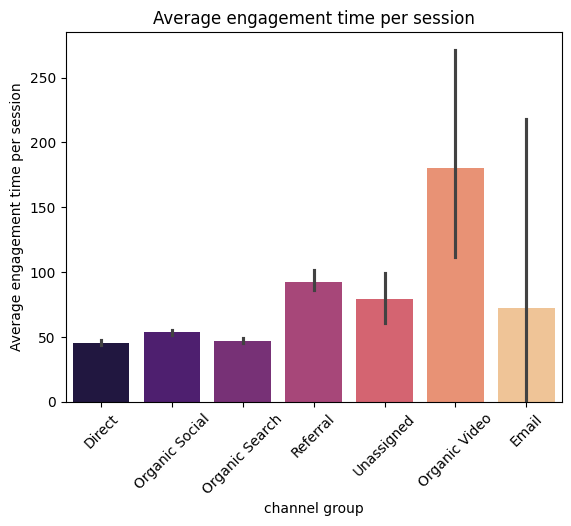

In [34]:
# Average engagement time by channel

plt.Figure(figsize=(8,5))
sns.barplot(data=df, x="channel group", y="Average engagement time per session", estimator=np.mean, palette='magma')
plt.title("Average engagement time per session")
plt.xticks(rotation=45)
plt.show()

C:\Users\JAY\AppData\Local\Temp\ipykernel_23836\1142641594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="channel group", y="Engagement rate", palette="coolwarm")


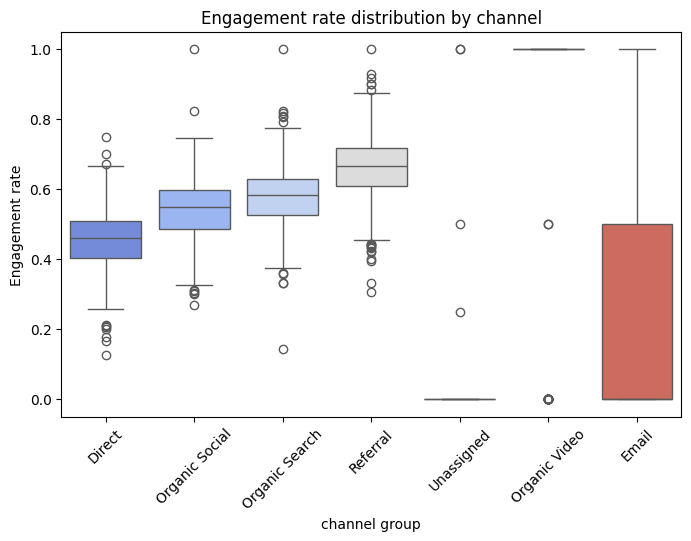

In [35]:
# engagement rate distrinution by channel 

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="channel group", y="Engagement rate", palette="coolwarm")
plt.title("Engagement rate distribution by channel")
plt.xticks(rotation=45)
plt.show()

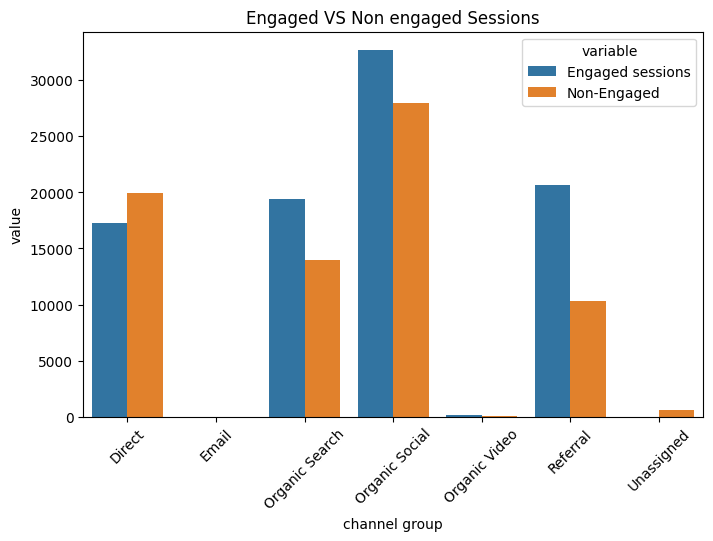

In [39]:
# Engaged vs non engaged sessions 

sessions_df = df.groupby("channel group")[["Sessions", "Engaged sessions"]].sum().reset_index()
sessions_df['Non-Engaged']= sessions_df['Sessions'] - sessions_df['Engaged sessions']
sessions_df_melted = sessions_df.melt(id_vars="channel group", value_vars=["Engaged sessions", "Non-Engaged"])

plt.figure(figsize=(8,5))
sns.barplot(data=sessions_df_melted, x= "channel group", y="value", hue="variable")
plt.title("Engaged VS Non engaged Sessions")
plt.xticks(rotation=45)
plt.show()

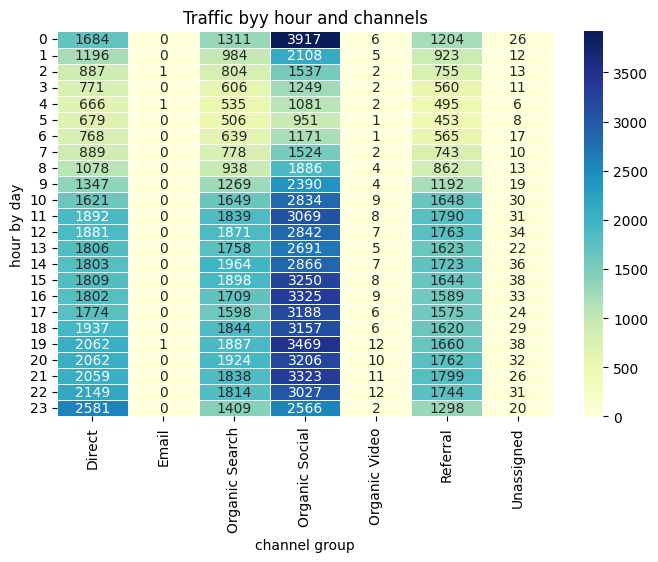

In [44]:
# Traffic by hour and channel 

heatmap_data= df.groupby(["hour", "channel group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5, annot=True, fmt=".0f")
plt.title("Traffic byy hour and channels")
plt.xlabel("channel group")
plt.ylabel("hour by day")
plt.show()

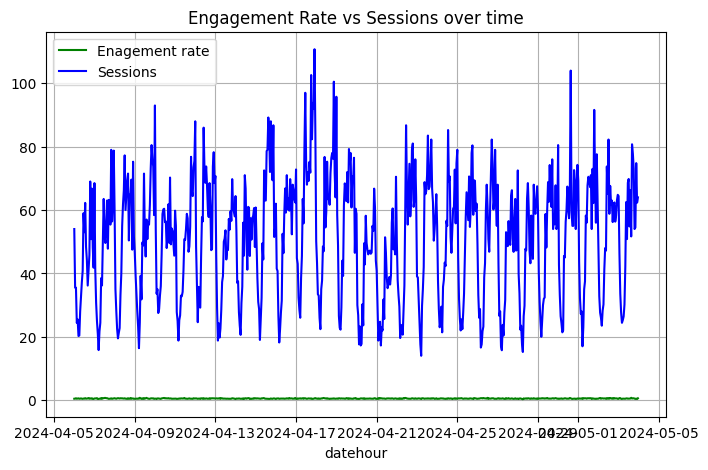

In [48]:
#  Engagement rate Vs Session over time 

df_pot = df.groupby("datehour")[["Engagement rate", "Sessions"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(df_pot['datehour'],df_pot['Engagement rate'], label="Enagement rate", color="green")
plt.plot(df_pot['datehour'], df_pot['Sessions'], label ="Sessions", color="blue" )
plt.title("Engagement Rate vs Sessions over time")
plt.xlabel("datehour")
plt.legend()
plt.grid()
plt.show()